In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pynwb import NWBHDF5IO

In [ ]:
path = "data/AO026_20181122_180943.nwb"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()

    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])

    unique_areas, counts = np.unique(areas, return_counts=True)
    idx = np.argsort(-counts)

    print("Top areas:")
    for a, c in zip(unique_areas[idx][:30], counts[idx][:30]):
        print(f"{a}: {c}")

Top areas:
mPFC: 51
wS1: 30


In [13]:
THIS_AREA = "wS1"

with NWBHDF5IO(path, "r") as io:
    nwb = io.read()

    #sélection des unités
    areas = nwb.units["Target_area"].data[:]
    areas = np.array([a.decode() if isinstance(a, (bytes, bytearray)) else a for a in areas])
    unit_mask = (areas == THIS_AREA)

    print("Units in area:", unit_mask.sum())

    spike_times_all = nwb.units["spike_times"].data[:]
    spike_times = [np.asarray(spike_times_all[i]) for i in range(len(spike_times_all)) if unit_mask[i]]

    trial_stop = np.asarray(nwb.trials["stop_time"].data[:], dtype=float)
    duration = float(trial_stop.max())

print("Selected units:", len(spike_times), "Duration (s):", duration)

Units in area: 30
Selected units: 30 Duration (s): 3882.8815666666665


In [14]:
bin_size = 0.01
n_bins = int(np.floor(duration / bin_size))
edges = np.linspace(0.0, n_bins * bin_size, n_bins + 1)

AP = np.zeros((len(spike_times), n_bins), dtype=np.float32)
for i, st in enumerate(spike_times):
    st = st[(st >= 0) & (st < n_bins * bin_size)]
    AP[i], _ = np.histogram(st, bins=edges)

print("AP shape (units x timebins):", AP.shape)
print("Mean pop activity shape:", AP.mean(axis=0).shape)

AP shape (units x timebins): (30, 388288)
Mean pop activity shape: (388288,)


In [15]:
with NWBHDF5IO(path, "r") as io:
    nwb = io.read()
    tr = nwb.trials.to_dataframe()

stim_trials = tr[tr["whisker_stim"] == 1].copy()
catch_trials = tr[tr["no_stim"] == 1].copy()

stim_times = stim_trials["whisker_stim_time"].to_numpy(dtype=float)
stim_amps = stim_trials["whisker_stim_amplitude"].to_numpy()

catch_times = catch_trials["no_stim_time"].to_numpy(dtype=float)

print("nb stim:", len(stim_times), "nb catch:", len(catch_times))
print("amps:", np.unique(stim_amps))

nb stim: 146 nb catch: 143
amps: [1. 2. 3. 4.]


In [16]:
def event_triggered(signal_1d, event_times, bin_size, t_before, t_after):
    pt_bef = int(round(t_before / bin_size))
    pt_aft = int(round(t_after / bin_size))
    win = pt_bef + pt_aft + 1
    out = []
    n = len(signal_1d)
    for ev in event_times:
        c = int(round(ev / bin_size))
        i0, i1 = c - pt_bef, c + pt_aft
        if i0 < 0 or i1 >= n:
            continue
        out.append(signal_1d[i0:i1+1])
    return np.stack(out, axis=0) if len(out) else np.zeros((0, win), dtype=signal_1d.dtype)

In [17]:
bin_size = 0.01
t_before = 0.5
t_after = 1.0

#matrice moyenne par unité autour des événements
stim_avg_units = np.stack([
    event_triggered(AP[i], stim_times, bin_size, t_before, t_after).mean(axis=0)
    for i in range(AP.shape[0])
], axis=0)

catch_avg_units = np.stack([
    event_triggered(AP[i], catch_times, bin_size, t_before, t_after).mean(axis=0)
    for i in range(AP.shape[0])
], axis=0)

print("stim_avg_units:", stim_avg_units.shape, "catch_avg_units:", catch_avg_units.shape)

stim_avg_units: (30, 151) catch_avg_units: (30, 151)


In [18]:
stim_bins = slice(50, 55)  # ~ 0 à +50 ms

pop_stim = stim_avg_units[:, stim_bins].mean(axis=1)
pop_catch = catch_avg_units[:, stim_bins].mean(axis=1)

CD = pop_stim - pop_catch
CD = CD / (np.linalg.norm(CD) + 1e-12)

print("CD shape:", CD.shape, "norm:", np.linalg.norm(CD))

CD shape: (30,) norm: 0.0


In [19]:
proj = CD @ AP  # (timebins,)
print("proj:", proj.shape)

proj: (388288,)


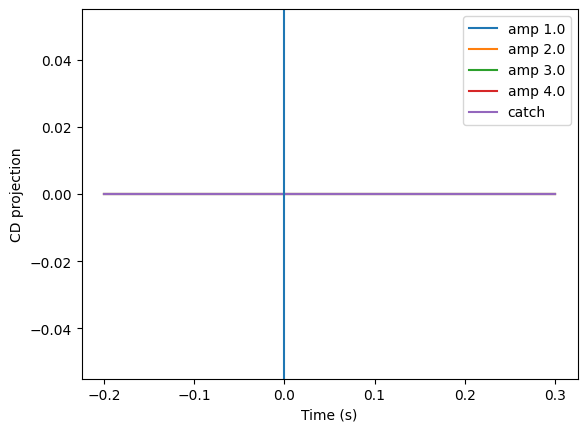

In [20]:
import matplotlib.pyplot as plt
import numpy as np

t_bef_plot = 0.2
t_aft_plot = 0.3
tv = np.linspace(-t_bef_plot, t_aft_plot, int(round((t_bef_plot+t_aft_plot)/bin_size)) + 1)

plt.figure()
for amp in np.unique(stim_amps):
    times = stim_times[stim_amps == amp]
    M = event_triggered(proj, times, bin_size, t_bef_plot, t_aft_plot)
    if M.shape[0]:
        plt.plot(tv, M.mean(axis=0), label=f"amp {amp}")

M0 = event_triggered(proj, catch_times, bin_size, t_bef_plot, t_aft_plot)
if M0.shape[0]:
    plt.plot(tv, M0.mean(axis=0), label="catch")

plt.axvline(0)
plt.xlabel("Time (s)")
plt.ylabel("CD projection")
plt.legend()
plt.show()